
# Time Series Forecasting — Practical Case Studies in Python

This notebook supports a **6-hour master-level lecture**. It contains practical Python examples for:

1. Hotel occupancy forecasting
2. Retail sales / seasonal demand forecasting
3. Random walk and naive benchmarks
4. EWMA, exponential smoothing and Holt-Winters
5. Decomposition
6. Stationarity testing
7. ACF and PACF
8. AR, MA, ARMA and ARIMA
9. Forecast evaluation
10. Multivariate forecasting with VAR
11. Non-linear forecasting using feature engineering and Random Forest

The notebook uses generated datasets so it can run without external downloads.


In [5]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

np.random.seed(42)


## Helper Functions

In [6]:
def evaluate_forecast(actual, forecast, model_name='Model'):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / np.maximum(np.abs(actual), 1e-8))) * 100
    return pd.DataFrame({
        'Model': [model_name],
        'MAE': [mae],
        'RMSE': [rmse],
        'MAPE (%)': [mape]
    })


def plot_train_test_forecast(train, test, forecast, title):
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train.values, label='Train')
    plt.plot(test.index, test.values, label='Test')
    plt.plot(test.index, forecast, label='Forecast')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()



## Case Study 1: Monthly Hotel Occupancy Forecasting

Business problem: A seaside hotel wants to forecast monthly occupancy to support staffing, pricing and procurement decisions.

The series includes:

- Upward long-term trend
- Strong summer seasonality
- Random noise


In [7]:
# Generate monthly hotel occupancy data
months = pd.date_range(start='2018-01-01', periods=84, freq='MS')
trend = np.linspace(45, 68, len(months))
seasonality = 18 * np.sin(2 * np.pi * (months.month - 5) / 12)
noise = np.random.normal(0, 4, len(months))
occupancy = np.clip(trend + seasonality + noise, 15, 98)

hotel = pd.DataFrame({'occupancy_rate': occupancy}, index=months)
hotel.head()


,occupancy_rate
2018-01-01,31.398399
2018-02-01,26.724051
2018-03-01,32.556514
2018-04-01,42.923445
2018-05-01,45.171820


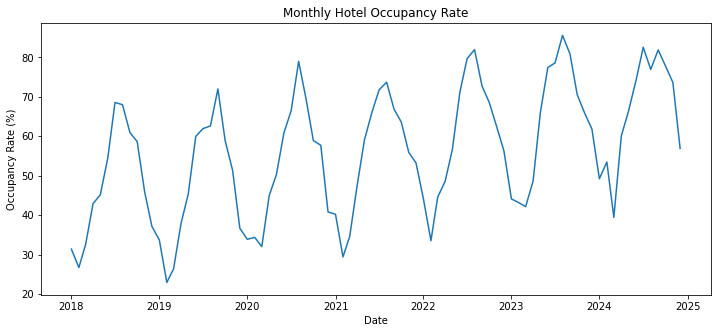

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(hotel.index, hotel['occupancy_rate'])
plt.title('Monthly Hotel Occupancy Rate')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate (%)')
plt.show()


### Train/Test Split

In [9]:
train = hotel['occupancy_rate'].iloc[:-12]
test = hotel['occupancy_rate'].iloc[-12:]

print('Train period:', train.index.min().date(), 'to', train.index.max().date())
print('Test period:', test.index.min().date(), 'to', test.index.max().date())


Train period: 2018-01-01 to 2023-12-01
Test period: 2024-01-01 to 2024-12-01


### Baseline 1: Naive Forecast / Random Walk

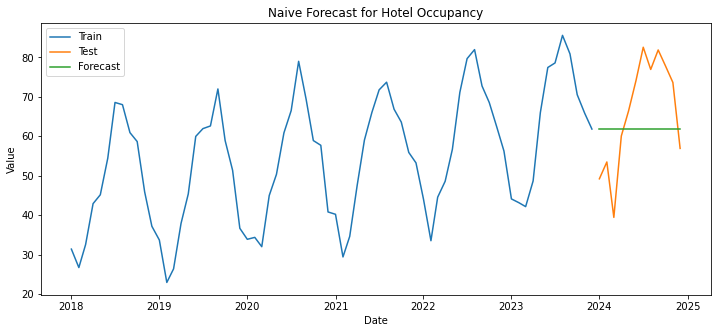

,Model,MAE,RMSE,MAPE (%)
0,Naive / Random Walk,12.554222,14.104282,19.90907


In [10]:
naive_forecast = np.repeat(train.iloc[-1], len(test))
plot_train_test_forecast(train, test, naive_forecast, 'Naive Forecast for Hotel Occupancy')
evaluate_forecast(test, naive_forecast, 'Naive / Random Walk')


### Baseline 2: Seasonal Naive Forecast

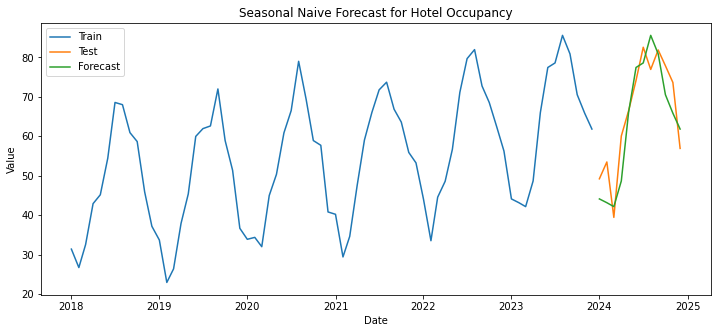

,Model,MAE,RMSE,MAPE (%)
0,Seasonal Naive,5.576281,6.525647,8.876381


In [11]:
seasonal_naive_forecast = train.iloc[-12:].values
plot_train_test_forecast(train, test, seasonal_naive_forecast, 'Seasonal Naive Forecast for Hotel Occupancy')
evaluate_forecast(test, seasonal_naive_forecast, 'Seasonal Naive')


## EWMA / Simple Exponential Smoothing

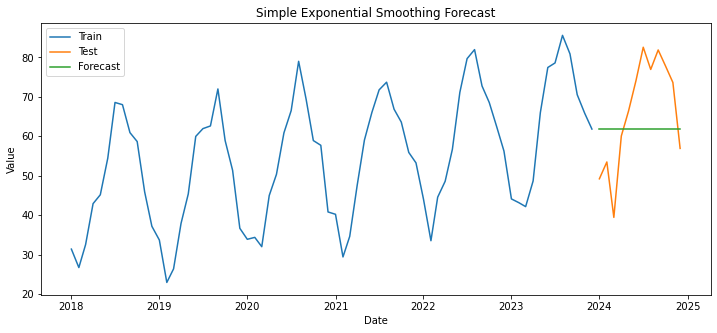

,Model,MAE,RMSE,MAPE (%)
0,Simple Exponential Smoothing,12.554222,14.104282,19.90907


In [12]:
ses_model = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses_model.forecast(len(test))
plot_train_test_forecast(train, test, ses_forecast, 'Simple Exponential Smoothing Forecast')
evaluate_forecast(test, ses_forecast, 'Simple Exponential Smoothing')


## Holt Linear Trend Method

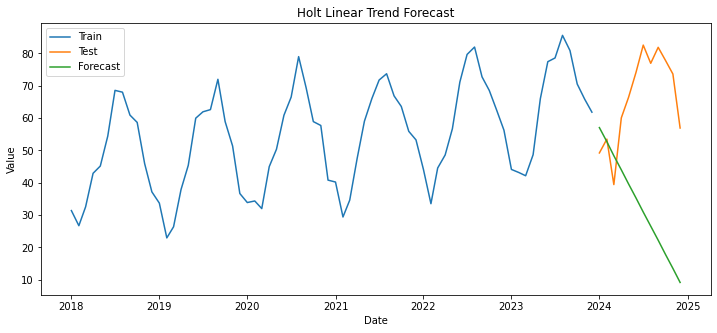

,Model,MAE,RMSE,MAPE (%)
0,Holt Linear Trend,35.723708,41.70819,50.232692


In [13]:
holt_model = Holt(train).fit(optimized=True)
holt_forecast = holt_model.forecast(len(test))
plot_train_test_forecast(train, test, holt_forecast, 'Holt Linear Trend Forecast')
evaluate_forecast(test, holt_forecast, 'Holt Linear Trend')


## Holt-Winters Seasonal Forecast

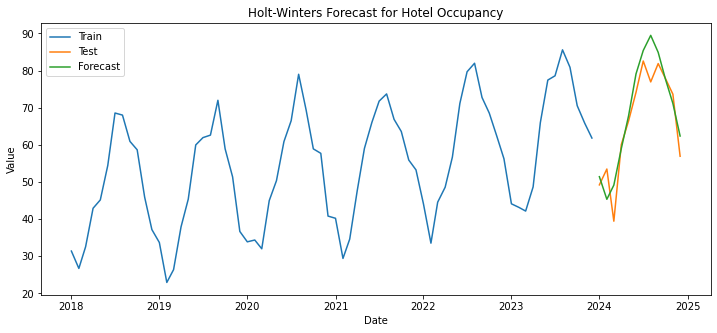

,Model,MAE,RMSE,MAPE (%)
0,Holt-Winters Additive,4.495643,5.799153,7.620244


In [14]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test))
plot_train_test_forecast(train, test, hw_forecast, 'Holt-Winters Forecast for Hotel Occupancy')
evaluate_forecast(test, hw_forecast, 'Holt-Winters Additive')


## Decomposition

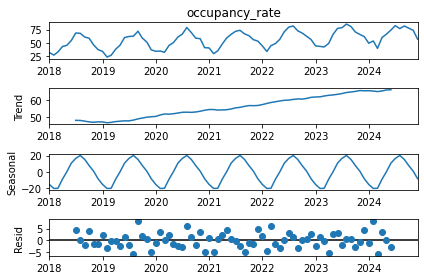

In [15]:
decomposition = seasonal_decompose(hotel['occupancy_rate'], model='additive', period=12)
decomposition.plot()
plt.show()


## Stationarity Test: Augmented Dickey-Fuller

In [16]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF test for {name}')
    print(f'ADF statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print('Interpretation: likely stationary')
    else:
        print('Interpretation: likely non-stationary')

adf_test(hotel['occupancy_rate'], 'Hotel Occupancy')


ADF test for Hotel Occupancy
ADF statistic: 0.2543
p-value: 0.9752
Interpretation: likely non-stationary


ADF test for Differenced Hotel Occupancy
ADF statistic: -6.0226
p-value: 0.0000
Interpretation: likely stationary


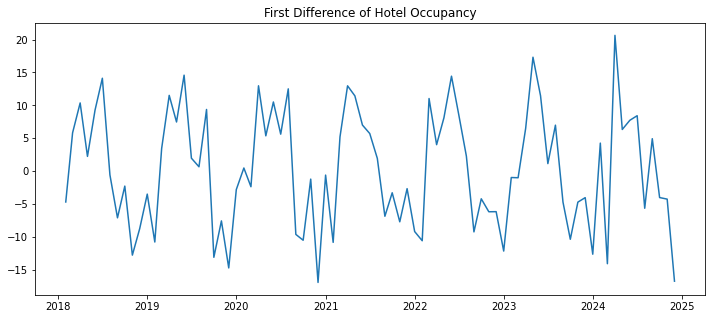

In [23]:
hotel_diff = hotel['occupancy_rate'].diff().dropna()
adf_test(hotel_diff, 'Differenced Hotel Occupancy')

plt.figure(figsize=(12, 5))
plt.plot(hotel_diff.index, hotel_diff)
plt.title('First Difference of Hotel Occupancy')
plt.show()


## ACF and PACF

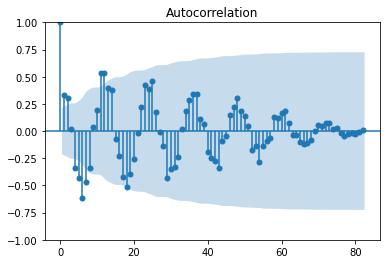

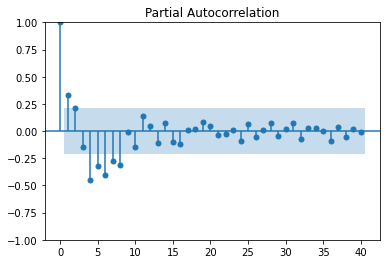

In [33]:
plot_acf(hotel_diff, lags=82) # two years before
plt.show()

plot_pacf(hotel_diff, lags=40, method='ywm')
plt.show()


## ARIMA Modelling

In [49]:
# ARIMA example: p=1, d=1, q=1
arima_model = ARIMA(train, order=(12, 1, 6)).fit()
print(arima_model.summary())


                               SARIMAX Results                                
Dep. Variable:         occupancy_rate   No. Observations:                   72
Model:                ARIMA(12, 1, 6)   Log Likelihood                -197.704
Date:                Sat, 25 Apr 2026   AIC                            433.407
Time:                        11:15:01   BIC                            476.398
Sample:                    01-01-2018   HQIC                           450.503
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1333      0.529     -2.141      0.032      -2.171      -0.096
ar.L2         -0.7792      0.569     -1.369      0.171      -1.894       0.336
ar.L3         -0.0465      0.522     -0.089      0.9

In [53]:
# ARMA model 
# ARMA example: p=1, d=0, q=1
arma_model = ARIMA(train, order=(12, 0, 6)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:         occupancy_rate   No. Observations:                   72
Model:                ARIMA(12, 0, 6)   Log Likelihood                -199.493
Date:                Sat, 25 Apr 2026   AIC                            438.987
Time:                        11:19:11   BIC                            484.520
Sample:                    01-01-2018   HQIC                           457.114
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.4397     14.179      3.840      0.000      26.650      82.229
ar.L1         -0.6045      0.463     -1.305      0.192      -1.513       0.304
ar.L2          0.3740      0.223      1.677      0.0

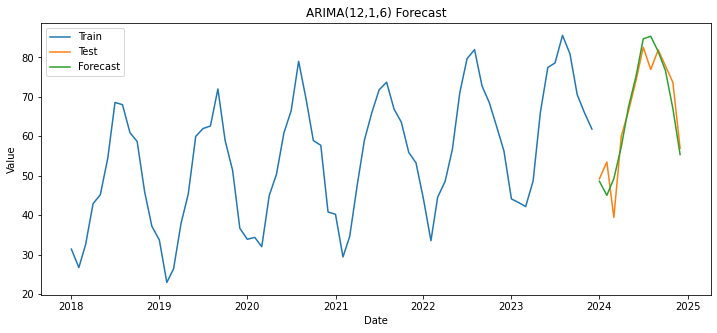

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(12,1,6)",3.673322,5.012086,6.402953


In [50]:
arima_forecast = arima_model.forecast(steps=len(test))
plot_train_test_forecast(train, test, arima_forecast, 'ARIMA(12,1,6) Forecast')
evaluate_forecast(test, arima_forecast, 'ARIMA(12,1,6)')


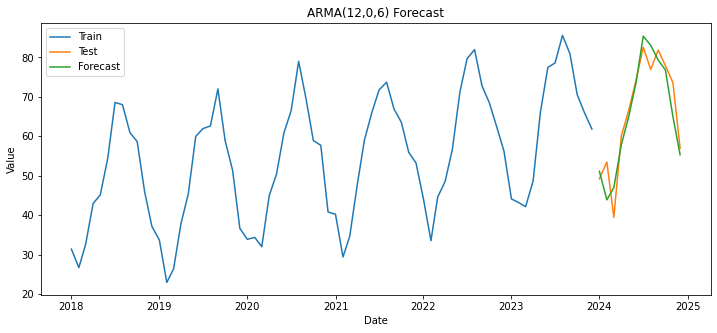

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(12,0,6)",3.845468,4.914593,6.50916


In [56]:
arma_forecast = arma_model.forecast(steps=len(test))
plot_train_test_forecast(train, test, arma_forecast, 'ARMA(12,0,6) Forecast')
evaluate_forecast(test, arma_forecast, 'ARIMA(12,0,6)')

## Residual Diagnostics

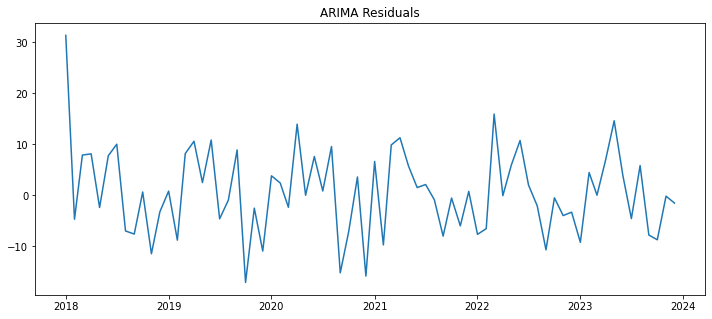

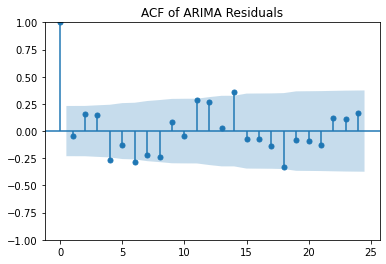

,lb_stat,lb_pvalue
10,26.532421,0.003086


In [21]:
residuals = arima_model.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.show()

plot_acf(residuals.dropna(), lags=24)
plt.title('ACF of ARIMA Residuals')
plt.show()

acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)


## Comparing Forecast Models

In [51]:
results = pd.concat([
    evaluate_forecast(test, naive_forecast, 'Naive / Random Walk'),
    evaluate_forecast(test, seasonal_naive_forecast, 'Seasonal Naive'),
    evaluate_forecast(test, ses_forecast, 'Simple Exponential Smoothing'),
    evaluate_forecast(test, holt_forecast, 'Holt Linear Trend'),
    evaluate_forecast(test, hw_forecast, 'Holt-Winters Additive'),
    evaluate_forecast(test, arima_forecast, 'ARIMA(12,1,6)')
], ignore_index=True)

results.sort_values('RMSE')


,Model,MAE,RMSE,MAPE (%)
5,"ARIMA(12,1,6)",3.673322,5.012086,6.402953
4,Holt-Winters Additive,4.495643,5.799153,7.620244
1,Seasonal Naive,5.576281,6.525647,8.876381
2,Simple Exponential Smoothing,12.554222,14.104282,19.909070
0,Naive / Random Walk,12.554222,14.104282,19.909070
3,Holt Linear Trend,35.723708,41.708190,50.232692



## Case Study 2: Retail Sales with Trend and Seasonality

Business problem: A retailer wants to forecast monthly sales volume to prepare inventory and marketing campaigns.


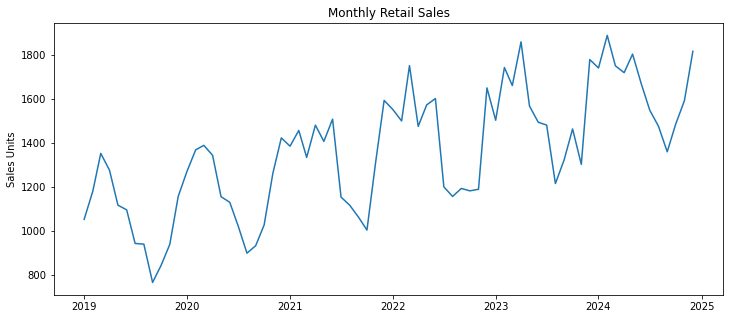

In [57]:
dates = pd.date_range(start='2019-01-01', periods=72, freq='MS')
trend = np.linspace(1000, 1700, len(dates))
season = 250 * np.sin(2 * np.pi * dates.month / 12) + 180 * (dates.month == 12)
noise = np.random.normal(0, 90, len(dates))
sales = trend + season + noise

retail = pd.DataFrame({'sales': sales}, index=dates)

plt.figure(figsize=(12, 5))
plt.plot(retail.index, retail['sales'])
plt.title('Monthly Retail Sales')
plt.ylabel('Sales Units')
plt.show()


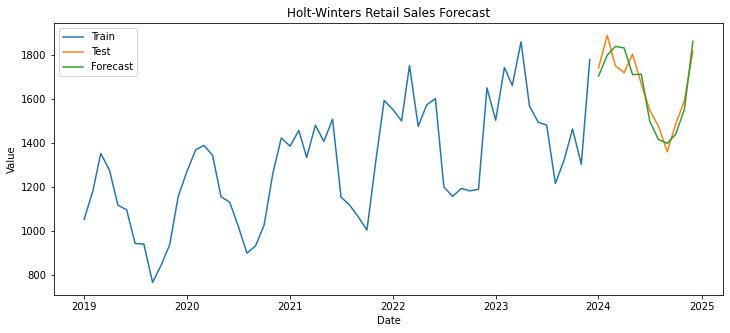

,Model,MAE,RMSE,MAPE (%)
0,Retail Holt-Winters,62.049995,67.030883,3.709157


In [58]:
retail_train = retail['sales'].iloc[:-12]
retail_test = retail['sales'].iloc[-12:]

retail_hw = ExponentialSmoothing(
    retail_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

retail_forecast = retail_hw.forecast(12)
plot_train_test_forecast(retail_train, retail_test, retail_forecast, 'Holt-Winters Retail Sales Forecast')
evaluate_forecast(retail_test, retail_forecast, 'Retail Holt-Winters')


## Case Study 3: Multivariate Forecasting with Hotel Occupancy, ADR and Marketing Spend

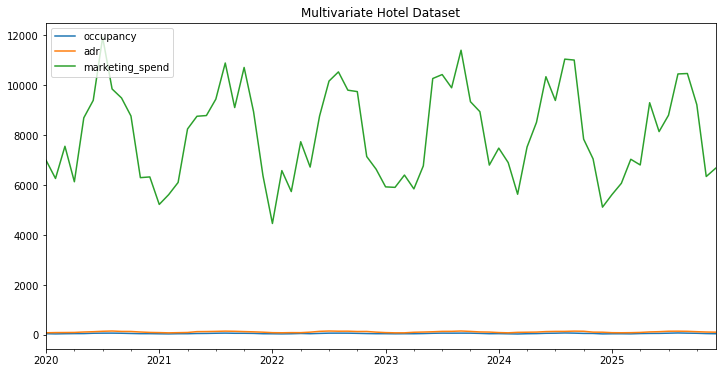

In [60]:
dates = pd.date_range(start='2020-01-01', periods=72, freq='MS')
season = np.sin(2 * np.pi * (dates.month - 5) / 12)
marketing_spend = 8000 + 2500 * season + np.random.normal(0, 800, len(dates))
adr = 120 + 30 * season + np.random.normal(0, 6, len(dates))
occupancy = 55 + 13 * season + 0.0015 * marketing_spend - 0.08 * adr + np.random.normal(0, 3, len(dates))

multi = pd.DataFrame({
    'occupancy': occupancy,
    'adr': adr,
    'marketing_spend': marketing_spend
}, index=dates)

multi.plot(figsize=(12, 6), title='Multivariate Hotel Dataset')
plt.show()


In [61]:
multi_train = multi.iloc[:-12]
multi_test = multi.iloc[-12:]


multi_train_diff = multi_train.diff().dropna()

var_model = VAR(multi_train_diff)
var_results = var_model.fit(maxlags=4, ic='aic')
print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Apr, 2026
Time:                     11:36:39
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    22.5493
Nobs:                     55.0000    HQIC:                   21.6763
Log likelihood:          -776.087    FPE:                1.53721e+09
AIC:                      21.1259    Det(Omega_mle):     8.13382e+08
--------------------------------------------------------------------
Results for equation occupancy
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                     -0.180851         0.624586           -0.290           0.772
L1.occupancy              -0.258067         0.196476           -1.313           0.189
L1.adr                     0.269824 

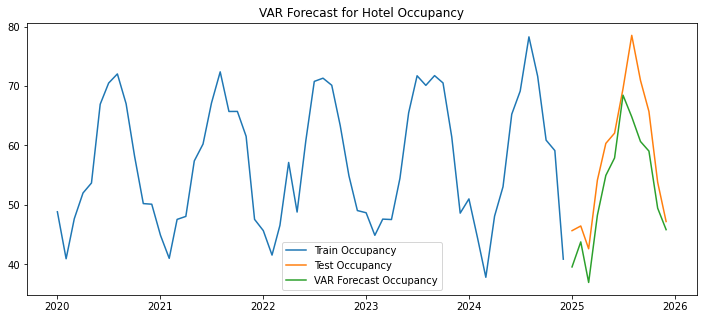

,Model,MAE,RMSE,MAPE (%)
0,VAR Occupancy Forecast,5.615155,6.569022,9.468573


In [62]:

lag_order = var_results.k_ar
forecast_input = multi_train_diff.values[-lag_order:]
var_diff_forecast = var_results.forecast(y=forecast_input, steps=12)
var_diff_forecast = pd.DataFrame(var_diff_forecast, index=multi_test.index, columns=multi.columns)


last_values = multi_train.iloc[-1]
var_level_forecast = var_diff_forecast.cumsum() + last_values

plt.figure(figsize=(12, 5))
plt.plot(multi_train.index, multi_train['occupancy'], label='Train Occupancy')
plt.plot(multi_test.index, multi_test['occupancy'], label='Test Occupancy')
plt.plot(var_level_forecast.index, var_level_forecast['occupancy'], label='VAR Forecast Occupancy')
plt.title('VAR Forecast for Hotel Occupancy')
plt.legend()
plt.show()

evaluate_forecast(multi_test['occupancy'], var_level_forecast['occupancy'], 'VAR Occupancy Forecast')


## Case Study 4: Non-Linear Forecasting with Random Forest

In [ ]:
# We reuse the retail sales data and create lag-based features.
ml_data = retail.copy()
ml_data['month'] = ml_data.index.month
ml_data['lag_1'] = ml_data['sales'].shift(1)
ml_data['lag_2'] = ml_data['sales'].shift(2)
ml_data['lag_3'] = ml_data['sales'].shift(3)
ml_data['lag_12'] = ml_data['sales'].shift(12)
ml_data['rolling_mean_3'] = ml_data['sales'].shift(1).rolling(3).mean()
ml_data['rolling_mean_6'] = ml_data['sales'].shift(1).rolling(6).mean()
ml_data = ml_data.dropna()

features = ['month', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6']
X = ml_data[features]
y = ml_data['sales']

X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_forecast = rf.predict(X_test)

plot_train_test_forecast(y_train, y_test, rf_forecast, 'Random Forest Forecast for Retail Sales')
evaluate_forecast(y_test, rf_forecast, 'Random Forest')


In [ ]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance


## Case Study 5: Forecasting Web Traffic with Weekly Seasonality

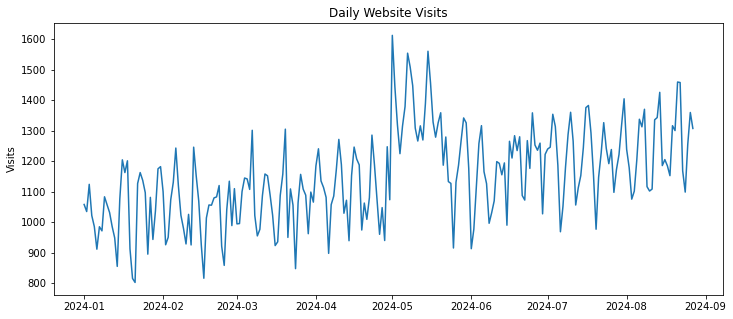

In [63]:
days = pd.date_range(start='2024-01-01', periods=240, freq='D')
weekly = 120 * np.sin(2 * np.pi * days.dayofweek / 7)
trend = np.linspace(1000, 1250, len(days))
campaign = np.where((days >= '2024-05-01') & (days <= '2024-05-20'), 250, 0)
noise = np.random.normal(0, 70, len(days))
traffic = trend + weekly + campaign + noise

web = pd.DataFrame({'visits': traffic}, index=days)

plt.figure(figsize=(12, 5))
plt.plot(web.index, web['visits'])
plt.title('Daily Website Visits')
plt.ylabel('Visits')
plt.show()


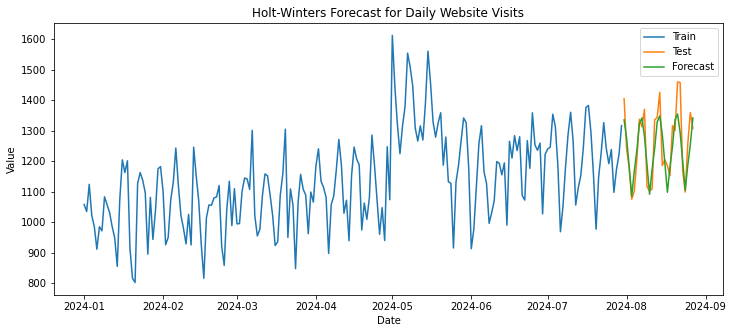

,Model,MAE,RMSE,MAPE (%)
0,Website Holt-Winters,54.446292,66.952973,4.236944


In [64]:
web_train = web['visits'].iloc[:-28]
web_test = web['visits'].iloc[-28:]

web_hw = ExponentialSmoothing(
    web_train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

web_forecast = web_hw.forecast(28)
plot_train_test_forecast(web_train, web_test, web_forecast, 'Holt-Winters Forecast for Daily Website Visits')
evaluate_forecast(web_test, web_forecast, 'Website Holt-Winters')


## Teaching Discussion Questions

1. Which model worked best for each dataset and why?
2. Did the best statistical model also make the most business sense?
3. What would happen if the test period contained an unexpected crisis or event?
4. Why should every advanced model be compared against a naive benchmark?
5. What external variables would improve the hotel occupancy forecast?
6. When would a non-linear model be preferable to ARIMA?


## Optional Student Exercise

Choose one of the datasets in this notebook and:

1. Create a new train/test split.
2. Fit at least three forecasting models.
3. Evaluate them using MAE, RMSE and MAPE.
4. Plot actual vs forecast values.
5. Write a short business interpretation of the best model.
